In [4]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/jvierstra/proj/vinson")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
from matplotlib import rcParams

from torch.utils.data import DataLoader
#from torchdata.stateful_dataloader import StatefulDataLoader

from torchinfo import summary
from tqdm import tqdm
from genome_tools.data.anndata import read_zarr_backed

rcParams["font.sans-serif"] = ["IBM Plex Sans"]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [79]:
def log_zscore_normalization(x, eta=1e-8):
    x = np.log(x + eta)
    return (x - x.mean()) / x.std()

def load_embeddings(filepath, motif_metadata_file):
    props = pd.read_table(filepath, index_col=0)
    metadata = pd.read_table(motif_metadata_file, index_col=0)
    props["cluster"] = metadata["cluster"]
    
    embeds = props.groupby(by="cluster").median().apply(log_zscore_normalization, axis=0)
    
    return embeds.T

embeddings = load_embeddings(
    "/net/seq/data2/projects/aabisheva/DHS_evolution/benchmark/hg38/tf_motif_v24_v2_regulome_all_0.01fdr/results/normalized/motif_proportions.tsv",
    "/net/seq/data2/projects/sabramov/ENCODE4/motifs_metadata.annotated.defunc.use_config.tsv"
)

#embeddings.to_csv("../data/embeddings.tsv", index=True, header=True, sep="\t")

# Testing dataloader, model & loss function

In [6]:
from vinson.datasets.sequence import SequenceEmbedDataset
from vinson.models.sequence import BassetTrunkEmbed, CellEmbedding, EmbedModel
from vinson.loss import PoissonNLL

# Create trunk model
embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

#Create model
model = EmbedModel(trunk_model, embed_model, regression=True)

In [7]:
summary(model)

Layer (type:depth-idx)                   Param #
EmbedModel                               --
├─BassetTrunkEmbed: 1-1                  --
│    └─Sequential: 2-1                   --
│    │    └─Conv1d: 3-1                  23,100
│    │    └─BatchNorm1d: 3-2             600
│    │    └─ReLU: 3-3                    --
│    │    └─MaxPool1d: 3-4               --
│    └─ReLU: 2-2                         --
│    └─Sequential: 2-3                   --
│    │    └─Conv1d: 3-5                  660,200
│    │    └─BatchNorm1d: 3-6             400
│    │    └─ReLU: 3-7                    --
│    │    └─MaxPool1d: 3-8               --
│    └─ReLU: 2-4                         --
│    └─Sequential: 2-5                   --
│    │    └─Conv1d: 3-9                  280,200
│    │    └─BatchNorm1d: 3-10            400
│    │    └─ReLU: 3-11                   --
│    │    └─MaxPool1d: 3-12              --
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       51,400
│    └

### Simulate the loss function

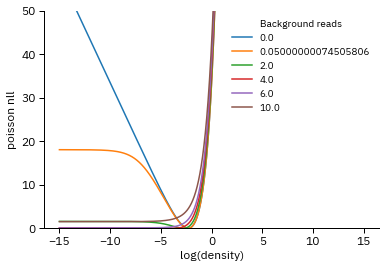

In [37]:
density = torch.tensor(0.1)
read_depth = torch.tensor(50e6)
bg_reads = torch.tensor([0, .05, 2, 4, 6, 10])

d = torch.linspace(-15, 15, 10_000)

for i in bg_reads:
    log_pred_counts = torch.logaddexp(d - torch.log(torch.tensor(1e6)) + torch.log(read_depth), torch.log(i))
    target_counts = density / 1e6 * read_depth

    loss = PoissonNLL(reduction="none")(log_pred_counts, target_counts)

    plt.plot(d, loss, label=f"{i}")

plt.ylim(0, 50)

plt.xlabel("log(density)")
plt.ylabel("poisson nll")


plt.legend(title="Background reads")

### Load in dataset and dataloader

In [99]:
samples_file = "/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/OCT8/epoch_1/data_OCT8_pos.batch1.val.h5"
negative_samples_file = "/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/OCT8/epoch_1/data_OCT8_neg.batch1.val.bed.gz"

# samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/AUG3/epoch_1/data_AUG3_pos.batch1.val.h5"
# negative_samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/AUG3/epoch_1/data_AUG3_neg.batch1.val.bed.gz"

# embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings_old_clustername.tsv"
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"
sample_genotype_file = (
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/meta+sample_ids.tsv"
)
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/all_variants_stats.bed.gz"

# General dataset params
dataset_kwargs = dict(
    negative_samples_rate=2,
    sample_genotype_file=sample_genotype_file,
    genotype_file=genotype_file,
    reverse_complement=False,
    jitter=0,
    noise=0,
)

dataset = SequenceEmbedDataset(
    samples_file,
    embeddings_file,
    fasta_file,
    negative_samples_file=negative_samples_file,
    **dataset_kwargs,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

INFO:vinson.datasets.sequence:Opening samples file.
INFO:vinson.datasets.sequence:Loading embeddings.
INFO:vinson.datasets.sequence:Sampling from negative examples file...
INFO:vinson.datasets.sequence:Loading genotype metadata.


## Load model checkpoint

In [100]:
# Create trunk model
embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

model_predict = EmbedModel.load_from_checkpoint("../models/data_OCT8_with_warmup_and_decay_v2/checkpoints/epoch=0-step=1401760-val_loss=25.82.ckpt", trunk=trunk_model, embed=embed_model)
#model_predict = EmbedModel.load_from_checkpoint("../models/data_AUG3_with_warmup_and_decay_v2/checkpoints/epoch=3-step=1851994-val_loss=16.16.ckpt", trunk=trunk_model, embed=embed_model)

model_predict = model_predict.eval().to("cpu")

### Predict variants (random batch)

In [101]:
import logging
logging.getLogger().setLevel(logging.INFO)

batch = next(iter(dataloader))

X_seq, X_embed, indicator, density, bg, read_depth, sample_id, chrom, mid, weight = (
    batch["ohe_seq"],
    batch["embed"],
    batch["indicator"],
    batch["density"],
    batch["bg"],
    batch["read_depth"],
    batch["sample_id"],
    batch["chrom"],
    batch["mid"],
    batch["weight"],
)

INFO:root:AG71396 not found in samples to genotype file. (chr22:24437114-24438458)
INFO:root:No INDIV_ID for AG80341 samples to genotype file (indiv_id = NaN). (chr9:137118203-137119547)
INFO:root:No INDIV_ID for AG95524 samples to genotype file (indiv_id = NaN). (chr9:117348175-117349519)
INFO:root:AG71710 not found in samples to genotype file. (chr9:27385328-27386672)
INFO:root:No INDIV_ID for AG62120 samples to genotype file (indiv_id = NaN). (chr22:30968485-30969829)
INFO:root:AG71416 not found in samples to genotype file. (chr9:74727656-74729000)
INFO:root:AG71719 not found in samples to genotype file. (chr9:120413160-120414504)
INFO:root:AG62190 not found in samples to genotype file. (chr9:136996506-136997850)
INFO:root:AG71393 not found in samples to genotype file. (chr9:3975434-3976778)
INFO:root:No INDIV_ID for AG86513 samples to genotype file (indiv_id = NaN). (chr22:30252144-30253488)
INFO:root:No INDIV_ID for AG95491 samples to genotype file (indiv_id = NaN). (chr22:4259573

In [104]:
y_ = model_predict(X_seq, X_embed).squeeze().detach()
ps = torch.tensor(1e-6)

dens_min = 0.01

log_pred_counts = torch.logaddexp(y_ - torch.log(torch.tensor(1e6)) + torch.log(read_depth), torch.log(bg + ps))
log_pred_counts = log_pred_counts.detach()

target_counts = (density / 1e6 * read_depth) + ps
target_counts = target_counts.detach()

pred_total_density = log_pred_counts.exp() / read_depth * 1e6

loss = PoissonNLL(reduction="none")(log_pred_counts, target_counts)
loss *= weight

print(f"loss = {loss.mean()}")

density = torch.max(density, torch.tensor(dens_min))

loss = 25.340999603271484


#### Predicted vs. observed read counts

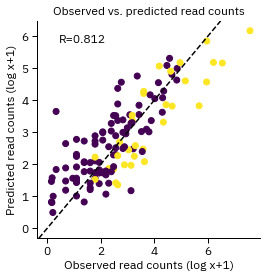

In [105]:
x = (target_counts + 1).log()
y = torch.logaddexp(log_pred_counts, torch.tensor(1).log())

plt.scatter(
    x,
    y,
    c=indicator,
)

plt.axline((0, 0), slope=1, color="k", ls="--")

plt.xlabel("Observed read counts (log x+1)")
plt.ylabel("Predicted read counts (log x+1)")

pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted read counts")

plt.gcf().set_size_inches(4, 4)

Text(0.5, 1.0, 'Observed vs. predicted density')

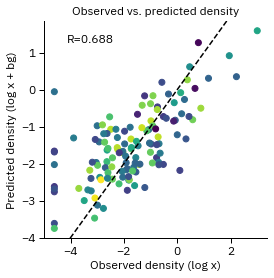

In [106]:
x = (density).log()
y = pred_total_density.log()

plt.scatter(x, y, c=torch.log(read_depth))
plt.gcf().set_size_inches(4, 4)

plt.axline((0, 0), slope=1, color="k", ls="--")

plt.xlabel("Observed density (log x)")
plt.ylabel("Predicted density (log x + bg)")


pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted density")

#### Predicted vs. observed peak densities

Text(0, 0.5, 'Peak density')

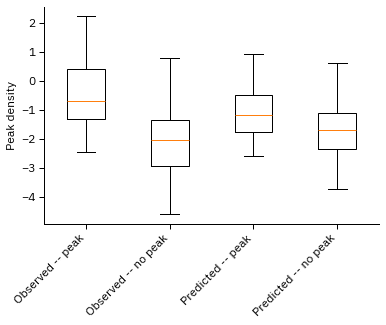

In [107]:
pred_w_peak = pred_total_density.log()[indicator.to(bool)]
pred_wo_peak = pred_total_density.log()[~indicator.to(bool)]


obs_w_peak = (density).log()[indicator.to(bool)]
obs_wo_peak = (density).log()[~indicator.to(bool)]

y = [
    obs_w_peak,
    obs_wo_peak,
    pred_w_peak,
    pred_wo_peak,
]

b = plt.boxplot(y, showfliers=False)

plt.xticks(
    np.arange(len(y)) + 1,
    labels=[
        "Observed -- peak",
        "Observed -- no peak",
        "Predicted -- peak",
        "Predicted -- no peak",
    ],
    rotation=45,
    ha="right",
)

plt.ylabel("Peak density")

#### Loss landscape

Text(0.5, 1.0, 'Loss landscape for batch')

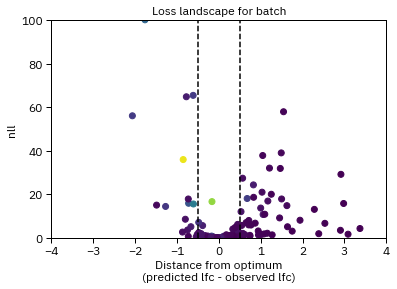

In [29]:
lfc = (torch.log(pred_total_density) - torch.log(density))

ax = plt.gca()

ax.scatter(lfc, loss, label="delta NLL", c=density)
ax.axvline(-0.5, color="k", ls="--")
ax.axvline(0.5, color="k", ls="--")

plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
ax.set_ylabel("nll")

ax.set_xlim(-4, 4)
ax.set_ylim(0, 100)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Loss landscape for batch")

#### Prediction error by peak density

Text(0.5, 1.0, 'Model prediction error by peak density')

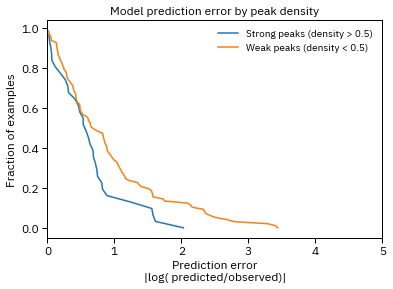

In [269]:
lfc_abs = lfc.abs()

x = lfc_abs[density > 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Strong peaks (density > 0.5)")

x = lfc_abs[density < 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Weak peaks (density < 0.5)")

plt.xlabel("Prediction error\n|log( predicted/observed)|")
plt.ylabel("Fraction of examples")

plt.legend()

plt.xlim(0, 5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Model prediction error by peak density")

(array([1., 0., 0., 3., 0., 0., 0., 0., 1., 5., 5., 4., 2., 6., 4., 4., 5.,
        2., 3., 2., 1., 0., 1., 2., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        1.]),
 array([-2.03060961, -1.90084374, -1.77107787, -1.641312  , -1.51154613,
        -1.38178027, -1.2520144 , -1.12224853, -0.99248266, -0.86271685,
        -0.73295099, -0.60318512, -0.47341922, -0.34365335, -0.2138875 ,
        -0.08412164,  0.04564423,  0.17541009,  0.30517596,  0.43494183,
         0.5647077 ,  0.69447356,  0.82423943,  0.9540053 ,  1.08377111,
         1.21353698,  1.34330285,  1.47306871,  1.60283458,  1.73260045,
         1.86236632,  1.99213219,  2.12189817,  2.25166392,  2.38142991,
         2.51119566]),
 <BarContainer object of 35 artists>)

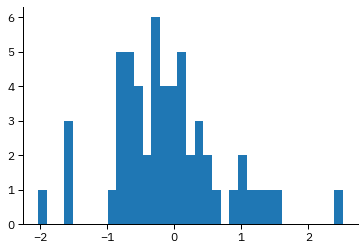

In [270]:
plt.hist(lfc[density>0.25])

### Contribution scores

In [204]:
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.models.helpers import _Exp

class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super(Wrapper, self).__init__()
        self.model = model
        self.exp = _Exp()
    def forward(self, seq, embed):
        return self.exp(self.model(seq, embed))

model_wrapper = Wrapper(model_predict)
model_wrapper = model_wrapper.eval()

In [205]:
print(torch.where(y_.exp() > 0.5))

(tensor([ 11,  16,  21,  22,  28,  29,  38,  43,  44,  49,  55,  60,  61,  70,
         71,  79,  93,  95,  98, 100, 101, 105, 117, 121]),)


In [236]:
i = 55
torch.exp(y_[i]), density[i]

(tensor(1.1605), tensor(0.7743))

In [237]:
# You to do this because dinucleotide shuffle cannot deal with ambiguous bases
_X = force_strict_ohe(X_seq[i : i + 1].clone())

Y_embed = X_embed[i : i + 1].clone()

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[500, :].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed_rand,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)


tensor([1.1921e-07, 0.0000e+00, 2.3842e-07, 1.1921e-07, 1.1921e-07, 0.0000e+00,
        1.1921e-07, 2.3842e-07, 0.0000e+00, 1.1921e-07, 1.1921e-07, 0.0000e+00,
        1.1921e-07, 1.7881e-07, 0.0000e+00, 0.0000e+00, 1.7881e-07, 2.3842e-07,
        5.9605e-08, 1.1921e-07], grad_fn=<AbsBackward0>)
tensor([1.3411e-07, 2.1607e-07, 1.4901e-07, 7.4506e-08, 4.0978e-08, 1.5646e-07,
        1.3411e-07, 7.4506e-08, 5.9605e-08, 1.6391e-07, 8.1956e-08, 2.9802e-08,
        1.1921e-07, 1.4715e-07, 7.4506e-08, 1.4901e-08, 1.1921e-07, 5.9605e-08,
        4.0978e-08, 9.6858e-08], grad_fn=<AbsBackward0>)


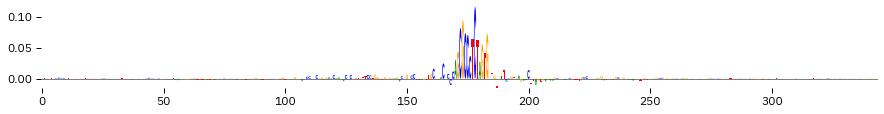

In [238]:
from tangermeme.plot import plot_logo

x = attrs[0][:, 500:-500]
t = torch.max(x).numpy()
fig, ax = plt.subplots()
plot_logo(x, ax=ax)
ax.set_ylim(top=t)
fig.set_size_inches(15, 1.5)

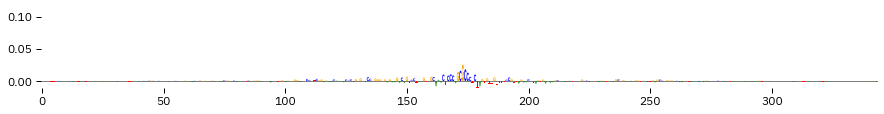

In [239]:
fig, ax = plt.subplots()
plot_logo(attrs_rand[0][:, 500:-500], ax=ax)
ax.set_ylim(top=t)
fig.set_size_inches(15, 1.5)

In [161]:
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise

In [50]:
Y_all = apply_pairwise(
    predict, 
    model_wrapper, 
    _X, #force_strict_ohe(X_seq), #_X, 
    args=(torch.as_tensor(dataset.embeddings_df.values),), device="cpu", verbose=True)


0it [00:00, ?it/s]/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)
4159it [00:54, 76.99it/s]


Text(0, 0.5, 'Number of samples')

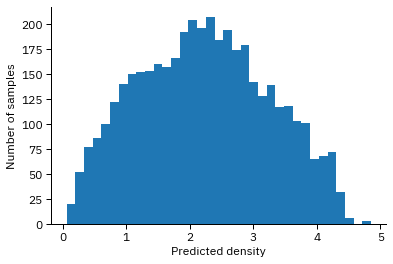

In [52]:
plt.hist(Y_all.squeeze())

plt.xlabel("Predicted density")
plt.ylabel("Number of samples")